In [2]:
import numpy
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
path = '.\data of biofilm(TINON BHAI).xlsx'
full_df  = pd.read_excel('.\data of biofilm(TINON BHAI).xlsx', sheet_name = "catkin")


<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tinon\AppData\Local\Temp\ipykernel_20848\148875920.py:5: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  path = '.\data of biofilm(TINON BHAI).xlsx'
C:\Users\tinon\AppData\Local\Temp\ipykernel_20848\148875920.py:6: SyntaxWarning: "\d" is an invalid escape sequence. Such sequenc

In [3]:
full_df

,absorbance,Ce,Initial concentration,Co-Ce,Qe,LN CE,LN QE,Ce/Qe,removal percentage(catkin)
0,0.18283,12.53496,20,7.46504,0.74650,2.52852,-0.29235,16.79156,37.32519
1,0.28417,18.60877,30,11.39123,1.13912,2.92363,0.13026,16.33604,37.97078
2,0.38148,24.44128,40,15.55872,1.55587,3.19627,0.44204,15.70905,38.89681
3,0.46373,29.37121,50,20.62879,2.06288,3.38002,0.72410,14.23797,41.25757
4,0.56008,35.14635,60,24.85365,2.48536,3.55952,0.91042,14.14133,41.42274


In [4]:
import numpy as np
full_df_ic = np.array(full_df["Initial concentration"])
full_df_ic

array([20, 30, 40, 50, 60])

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_full_df_ic = scaler.fit_transform(full_df_ic.reshape(-1,1))
#unsclaed_full_df_ic =
# reverse the scaling
denormalized_full_df_ic = scaler.inverse_transform(scaled_full_df_ic)
denormalized_full_df_ic,scaled_full_df_ic

(array([[20.],
        [30.],
        [40.],
        [50.],
        [60.]]),
 array([[-1.41421356],
        [-0.70710678],
        [ 0.        ],
        [ 0.70710678],
        [ 1.41421356]]))

In [6]:
"""
Kinetics data:
    Input: Time
    Output: Adsorption(qt)
"""

'\nKinetics data:\n    Input: Time\n    Output: Adsorption(qt)\n'

In [7]:
kinetics_df = pd.read_excel(path, sheet_name = 'catkin (pfo pso)')
kinetics_df

,Time,qt( catkin)
0,0,0.00000
1,10,0.72145
2,20,0.84218
3,30,0.85548
4,50,0.88510
5,80,0.99843
6,110,1.10776
7,140,1.15607
8,170,1.17853


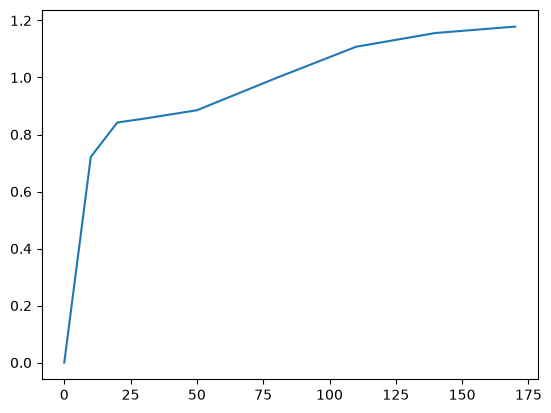

In [8]:
# plot the relation
import matplotlib.pyplot as plt
plt.plot(kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values)


In [9]:
## Normalize the value and test the model
## Start picking models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

X, y = kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values
# Do the scaling



In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV


pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('preprocessing', StandardScaler()),
    ('model', LinearRegression())
])

param_grid = {
    'poly__degree': [1, 2, 3]
}

loo = LeaveOneOut()
grid_search_model = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv = loo,
    scoring = 'neg_mean_squared_error'
)

grid_search_model.fit(X.reshape(-1,1),y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneOut()
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [11]:
grid_search_model.score

<bound method BaseSearchCV.score of GridSearchCV(cv=LeaveOneOut(),
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('preprocessing', StandardScaler()),
                                       ('model', LinearRegression())]),
             param_grid={'poly__degree': [1, 2, 3]},
             scoring='neg_mean_squared_error')>

In [12]:
grid_search_model.cv_results_

{'mean_fit_time': array([0.00133011, 0.00119093, 0.00136362]),
 'std_fit_time': array([2.61046810e-04, 5.07128323e-05, 1.64081072e-04]),
 'mean_score_time': array([0.0005605 , 0.00056815, 0.00058728]),
 'std_score_time': array([4.62269032e-05, 6.98775711e-05, 4.73092232e-05]),
 'param_poly__degree': masked_array(data=[1, 2, 3],
              mask=[False, False, False],
        fill_value=999999),
 'params': [{'poly__degree': 1}, {'poly__degree': 2}, {'poly__degree': 3}],
 'split0_test_score': array([-0.57388356, -0.50074749, -0.51626613]),
 'split1_test_score': array([-0.02424857, -0.08272226, -0.10166957]),
 'split2_test_score': array([-0.05865349, -0.07095882, -0.04039974]),
 'split3_test_score': array([-0.03847373, -0.02281579, -0.00065234]),
 'split4_test_score': array([-0.01416616, -0.00074981, -0.04872641]),
 'split5_test_score': array([-0.00879517, -0.02008814, -0.02400641]),
 'split6_test_score': array([-0.00477448, -0.01355513, -0.00577102]),
 'split7_test_score': array([-0.00

In [13]:
grid_search_model.best_score_, grid_search_model.best_params_

(np.float64(-0.08832981200372592), {'poly__degree': 1})

In [14]:
best_model = grid_search_model.best_estimator_
y_test_predict = best_model.predict(X.reshape(-1,1))
r2_score(y, y_test_predict)

0.5810980802566073

In [15]:
X,y

(array([  0,  10,  20,  30,  50,  80, 110, 140, 170]),
 array([0.     , 0.72145, 0.84218, 0.85548, 0.8851 , 0.99843, 1.10776,
        1.15607, 1.17853]))

In [16]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",1
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


In [17]:
print("X:")
print(X)

print("\ny:")
print(y)

print("\nNaN in X:", np.isnan(X).any())
print("NaN in y:", np.isnan(y).any())

X:
[  0  10  20  30  50  80 110 140 170]

y:
[0.      0.72145 0.84218 0.85548 0.8851  0.99843 1.10776 1.15607 1.17853]

NaN in X: False
NaN in y: False


In [18]:
from sklearn.model_selection import cross_val_predict
reshaped_X = X.reshape(-1,1)
loo_predictions = cross_val_predict(
    best_model,
    reshaped_X,
    y,
    cv = LeaveOneOut()
)

r2_result = r2_score(y,loo_predictions)
print(f"R2 result: {r2_result}")

R2 result: 0.22775725593498108


In [19]:
print(loo_predictions), y

[0.75755103 0.56573048 0.59999518 0.65933279 0.76607832 0.90464741
 1.03866241 1.19734383 1.44361419]


(None,
 array([0.     , 0.72145, 0.84218, 0.85548, 0.8851 , 0.99843, 1.10776,
        1.15607, 1.17853]))

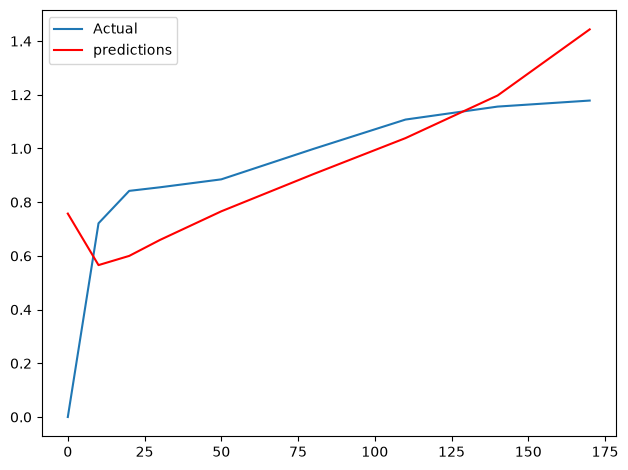

In [20]:
# plot the relation
import matplotlib.pyplot as plt
plt.plot(kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values, label = 'Actual')
plt.plot(kinetics_df['Time'].values, loo_predictions, c = 'red', label ='predictions')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
# The data
print(f"Input data: {X}\nOutput Data: {y}")
# Take the model:
# Prepare the data:
X = X.reshape(-1,1)
""""
Polynomial Degree(degree = 2, degree = 3)
RandomForest
GausianProbabilityRegression
"""
model_results_nmse = {
    "Poly_2":[],
    "Poly_3":[],
    "GPR":[],
    "RandomForest":[]
}
#Polynomiad Degree(degree = 2)
print("="*60)
print("Polynomial Model")
print("="*60)
polynomial_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree = 2)),
    ('preprocessing', StandardScaler()),
    ('model', Ridge())
])
print("="*60)
print("Cross Validation using LeaveOneOut")
print("="*60)
scores = cross_val_score(
    polynomial_pipeline,
    X,
    y,
    cv = LeaveOneOut(),
    scoring='neg_mean_squared_error'
).mean()
model_results_nmse['Poly_2'].append(scores.item())
#Polynomiad Degree(degree = 3)
print("="*60)
print("Polynomial Model(degree = 3)")
print("="*60)
polynomial_pipeline_3 = Pipeline([
    ('poly', PolynomialFeatures(degree = 3)),
    ('preprocessing', StandardScaler()),
    ('model', Ridge())
])
print("="*60)
print("Cross Validation using LeaveOneOut")
print("="*60)
scores_3 = cross_val_score(
    polynomial_pipeline_3,
    X,
    y,
    cv = LeaveOneOut(),
    scoring='neg_mean_squared_error').mean()

model_results_nmse['Poly_3'].append(scores_3.item())

# poly_model_degree2 prediction
poly_2_predictions = cross_val_predict(
    polynomial_pipeline,
    X,
    y,
    cv = LeaveOneOut()
)
r2_poly2= r2_score(y, poly_2_predictions)
print(f"Polynomial degree 3 r2 score: {r2_poly2}")
print(f"mean_squared_error: {mean_squared_error(y, poly_2_predictions)}")

poly_3_predictions = cross_val_predict(
    polynomial_pipeline_3,
    X,
    y,
    cv = LeaveOneOut()
)
r2_poly3= r2_score(y, poly_3_predictions)
print(f"Polynomial degree 3 r2 score: {r2_poly3}")
print(f"mean_squared_error: {mean_squared_error(y, poly_3_predictions)}")

Input data: [[  0]
 [ 10]
 [ 20]
 [ 30]
 [ 50]
 [ 80]
 [110]
 [140]
 [170]]
Output Data: [0.      0.72145 0.84218 0.85548 0.8851  0.99843 1.10776 1.15607 1.17853]
Polynomial Model
Cross Validation using LeaveOneOut
Polynomial Model(degree = 3)
Cross Validation using LeaveOneOut
Polynomial degree 3 r2 score: 0.2507865760731458
mean_squared_error: 0.08569569788091785
Polynomial degree 3 r2 score: 0.27638478322848525
mean_squared_error: 0.08276775217596838


In [ ]:
model_results_nmse

{'Poly_2': [-0.08569569788091785],
 'Poly_3': [-0.08276775217596838],
 'GPR': [],
 'RandomForest': []}

In [ ]:
## create gpr for 

In [ ]:
from typing import List
## Create a function
model_name = {
    'LinearRegression':None,
    'GaussianProbabilityRegression':None,
    'Ridge':None
}
for model_name, value in model_name.items():
    model_name = model_name()

def prediction(model_name:List):
    return None


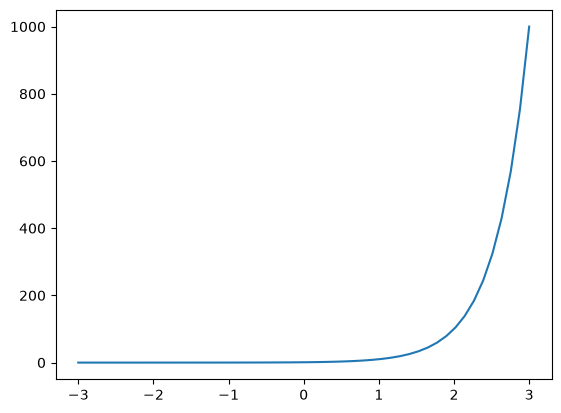

In [25]:
alphas = np.logspace(start = -3,stop = 3, num = 50)
x = np.linspace(-3,3,50)
plt.plot(x, alphas)

In [26]:
from sklearn.preprocessing import FunctionTransformer
log_transform = FunctionTransformer(lambda x: np.log1p(X))
log_transform

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...0022669342C40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


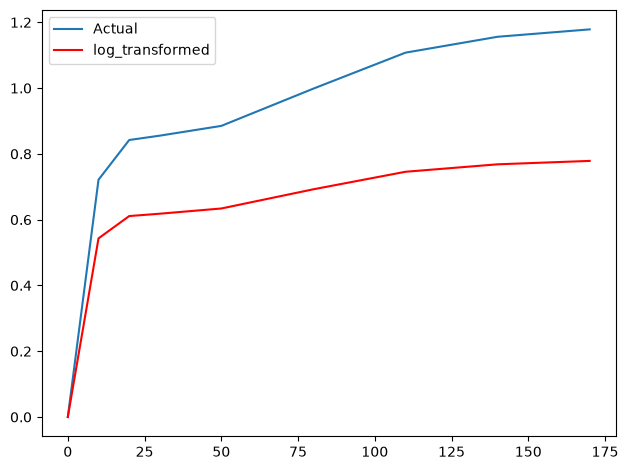

In [32]:
# now pass the adsorption through the log transformation
log_transformed_y = FunctionTransformer(lambda x: np.log1p(x))
y_transformed = log_transformed_y.fit_transform(y.reshape(-1, 1))
plt.plot(kinetics_df['Time'].values, kinetics_df['qt( catkin)'].values, label = 'Actual')
plt.plot(kinetics_df['Time'].values, y_transformed, c = 'red', label ='log_transformed')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
import numpy as np
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, SplineTransformer, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

X = np.array([0, 10, 20, 30, 50, 80, 110, 140, 170]).reshape(-1,1)
y = np.array([0., 0.72145, 0.84218, 0.85548, 0.8851, 0.99843, 1.10776, 1.15607, 1.17853])
loo = LeaveOneOut()

def eval_pipe(name, pipe):
    preds = cross_val_predict(pipe, X, y, cv=loo)
    r2 = r2_score(y, preds)
    mse = mean_squared_error(y, preds)
    print(f"{name:35s} R2={r2:.4f}  MSE={mse:.5f}")

# baseline: your poly2/poly3 + scaler + ridge(alpha=1)
eval_pipe("Poly2 + Scaler + Ridge(a=1)", Pipeline([
    ('poly', PolynomialFeatures(2)), ('sc', StandardScaler()), ('m', Ridge())
]))
eval_pipe("Poly3 + Scaler + Ridge(a=1)", Pipeline([
    ('poly', PolynomialFeatures(3)), ('sc', StandardScaler()), ('m', Ridge())
]))

# Poly2/3 + RidgeCV (alpha tuned automatically each fold)
alphas = np.logspace(-3, 3, 50)
eval_pipe("Poly2 + Scaler + RidgeCV", Pipeline([
    ('poly', PolynomialFeatures(2)), ('sc', StandardScaler()), ('m', RidgeCV(alphas=alphas))
]))
eval_pipe("Poly3 + Scaler + RidgeCV", Pipeline([
    ('poly', PolynomialFeatures(3)), ('sc', StandardScaler()), ('m', RidgeCV(alphas=alphas))
]))

# log(1+x) feature + Ridge
log_transform = FunctionTransformer(lambda x: np.log1p(x))
eval_pipe("log1p(X) + Ridge(a=1)", Pipeline([
    ('log', log_transform), ('sc', StandardScaler()), ('m', Ridge())
]))
eval_pipe("log1p(X) + RidgeCV", Pipeline([
    ('log', log_transform), ('sc', StandardScaler()), ('m', RidgeCV(alphas=alphas))
]))

# log1p(x) expanded to poly degree 2 (captures curvature around the log feature)
eval_pipe("Poly2(log1p(X)) + RidgeCV", Pipeline([
    ('log', log_transform), ('poly', PolynomialFeatures(2)), ('sc', StandardScaler()), ('m', RidgeCV(alphas=alphas))
]))

# Splines
eval_pipe("Spline(deg2,4knots) + RidgeCV", Pipeline([
    ('spl', SplineTransformer(degree=2, n_knots=4)), ('sc', StandardScaler()), ('m', RidgeCV(alphas=alphas))
]))


Poly2 + Scaler + Ridge(a=1)         R2=0.2508  MSE=0.08570
Poly3 + Scaler + Ridge(a=1)         R2=0.2764  MSE=0.08277
Poly2 + Scaler + RidgeCV            R2=0.3647  MSE=0.07266
Poly3 + Scaler + RidgeCV            R2=0.2172  MSE=0.08954
log1p(X) + Ridge(a=1)               R2=0.8397  MSE=0.01833
log1p(X) + RidgeCV                  R2=0.8644  MSE=0.01551
Poly2(log1p(X)) + RidgeCV           R2=0.6232  MSE=0.04310
Spline(deg2,4knots) + RidgeCV       R2=0.2793  MSE=0.08243


array([1.00000000e-04, 1.45634848e-04, 2.12095089e-04, 3.08884360e-04,
       4.49843267e-04, 6.55128557e-04, 9.54095476e-04, 1.38949549e-03,
       2.02358965e-03, 2.94705170e-03, 4.29193426e-03, 6.25055193e-03,
       9.10298178e-03, 1.32571137e-02, 1.93069773e-02, 2.81176870e-02,
       4.09491506e-02, 5.96362332e-02, 8.68511374e-02, 1.26485522e-01,
       1.84206997e-01, 2.68269580e-01, 3.90693994e-01, 5.68986603e-01,
       8.28642773e-01, 1.20679264e+00, 1.75751062e+00, 2.55954792e+00,
       3.72759372e+00, 5.42867544e+00, 7.90604321e+00, 1.15139540e+01,
       1.67683294e+01, 2.44205309e+01, 3.55648031e+01, 5.17947468e+01,
       7.54312006e+01, 1.09854114e+02, 1.59985872e+02, 2.32995181e+02,
       3.39322177e+02, 4.94171336e+02, 7.19685673e+02, 1.04811313e+03,
       1.52641797e+03, 2.22299648e+03, 3.23745754e+03, 4.71486636e+03,
       6.86648845e+03, 1.00000000e+04])

In [ ]:
df_filtered = kinetics_df[kinetics_df['Time']>0].copy()
t = df_filtered['Time'].values.reshape(-1,1)
qt_actual = df_filtered['qt( catkin)'].values

# =============================================================
# MODEL A: PSEUDO FIRST ORDER
# =============================================================
##Formula: $$\ln(q_e - q_t) = \ln(q_e) - k_1 t$$
qe_theo = qt_actual.max()

# Discard the value of qe_theo
valid_idx = qe_theo>df_filtered['qt( catkin)']
t_pfo = t[valid_idx]
qt_pfo = qt_actual[valid_idx]

y_pfo = np.log(qe_theo - qt_pfo)
pfo_model = LinearRegression()
pfo_model.fit(t_pfo, y_pfo)

# predict y and inverse math to get predict qt


array([0.72145, 0.84218, 0.85548, 0.8851 , 0.99843, 1.10776, 1.15607])

In [38]:
qe_theo

np.float64(1.17853)

In [ ]:
## What we get till now:
"""
the process: 
    1. The pipeline, which incorporates with preprocessing, and the model, is created and fitted to data.
    2. Pipeline along with cross_val_predict is used to get predictions for each data point using LeaveOneOut cross-validation.
    3. GridSearchCV is used to find the best hyperparameters for the model, and the best model is selected based on the mean squared error.
    4. The model is evaluated using LeaveOneOut cross-validation, and the R2 score and mean squared error are calculated.
    5. Different models are compared, including polynomial regression, log transformation, and spline regression.
    6. R2 can't be calculated directly from the model, but can be calculated using cross_val_predict to get predictions and then comparing with actual values.
    7. The pseudo-first-order model is implemented, and the theoretical maximum adsorption capacity (qe_theo) is calculated based on the maximum observed qt value.
"""

'\nthe process: \n\n\n\n\n'

array([ 10,  20,  30,  50,  80, 110, 140, 170])